In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [5]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [6]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9736842105263158


In [7]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [8]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9473684210526315


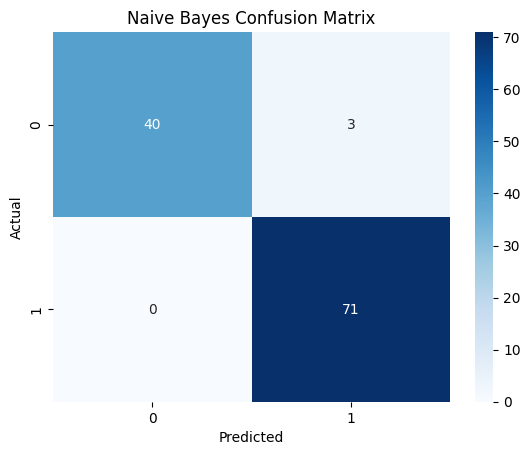

In [9]:
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

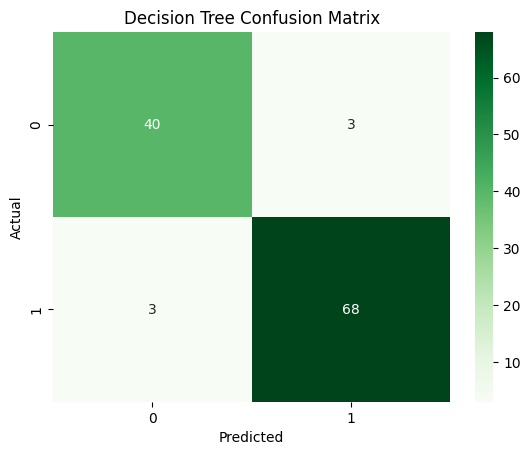

In [10]:
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
print("Naive Bayes Report\n")
print(classification_report(y_test, nb_pred))

print("Decision Tree Report\n")
print(classification_report(y_test, dt_pred))

Naive Bayes Report

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Decision Tree Report

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



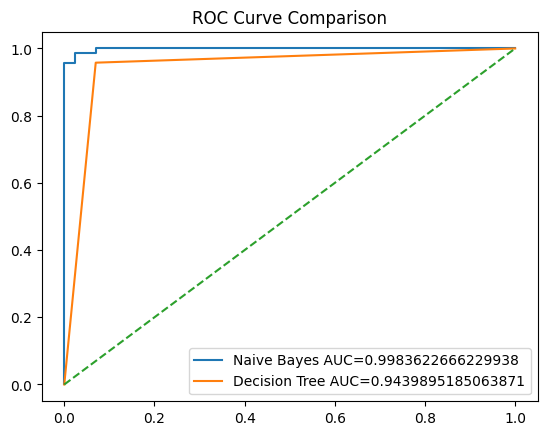

In [12]:
nb_prob = nb_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

roc_nb = auc(fpr_nb, tpr_nb)
roc_dt = auc(fpr_dt, tpr_dt)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes AUC="+str(roc_nb))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree AUC="+str(roc_dt))

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve Comparison")

plt.show()

In [13]:
results = pd.DataFrame({
    "Actual": y_test,
    "NaiveBayes": nb_pred,
    "DecisionTree": dt_pred
})

print(results.head())

     Actual  NaiveBayes  DecisionTree
204       1           1             1
70        0           0             0
131       0           0             0
431       1           1             1
540       1           1             1
